ConfigurableBoard: An upgrade to your Board that accepts dynamic thresholds (instead of hardcoded ones).

OptimizedEnsembleBacktester: A specific backtester that passes your Optuna parameters into the Board during the run.

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Data Loaded. Shape: (2743, 8)
Data prepared for tuning.
Loading Models...


[I 2025-11-27 00:11:13,767] A new study created in memory with name: no-name-fb73d2cc-402e-4d02-a393-9bd77ced68b3
[I 2025-11-27 00:11:13,794] Trial 0 finished with value: 40.8567235641209 and parameters: {'panic_fast': 0.02215609006867494, 'panic_slow': 0.02653807201190436, 'rebal_thresh': 0.08177345709393527}. Best is trial 0 with value: 40.8567235641209.
[I 2025-11-27 00:11:13,819] Trial 1 finished with value: 42.81395739907534 and parameters: {'panic_fast': 0.019058259149723374, 'panic_slow': 0.016736980148535207, 'rebal_thresh': 0.0373938843422673}. Best is trial 1 with value: 42.81395739907534.
[I 2025-11-27 00:11:13,845] Trial 2 finished with value: 23.488428366444456 and parameters: {'panic_fast': 0.023534310597922294, 'panic_slow': 0.017538419236412424, 'rebal_thresh': 0.0484784317280102}. Best is trial 1 with value: 42.81395739907534.
[I 2025-11-27 00:11:13,871] Trial 3 finished with value: 51.672438710967356 and parameters: {'panic_fast': 0.02895470447304589, 'panic_slow': 0.

Pre-computing agent signals...
Pre-computation complete.
Starting Optuna...


[I 2025-11-27 00:11:13,973] Trial 7 finished with value: 12.43678016934807 and parameters: {'panic_fast': 0.010606073663256476, 'panic_slow': 0.019865524589781976, 'rebal_thresh': 0.08544594956942533}. Best is trial 6 with value: 55.08829482301617.
[I 2025-11-27 00:11:13,998] Trial 8 finished with value: 22.03980743976595 and parameters: {'panic_fast': 0.012388542782679786, 'panic_slow': 0.015722480574243084, 'rebal_thresh': 0.08626554725790929}. Best is trial 6 with value: 55.08829482301617.
[I 2025-11-27 00:11:14,023] Trial 9 finished with value: 24.048879019855217 and parameters: {'panic_fast': 0.012029418565204945, 'panic_slow': 0.03448716450867974, 'rebal_thresh': 0.06423077386595259}. Best is trial 6 with value: 55.08829482301617.
[I 2025-11-27 00:11:14,051] Trial 10 finished with value: 78.72369954317186 and parameters: {'panic_fast': 0.017015973484041078, 'panic_slow': 0.03894068406626263, 'rebal_thresh': 0.09919173522794439}. Best is trial 10 with value: 78.72369954317186.
[I 


Best Params Found:
{'panic_fast': 0.017692702855416183, 'panic_slow': 0.03832892050476275, 'rebal_thresh': 0.06248608772060008}

Validating on Test Set with: Fast=0.0177, Slow=0.0383, Thresh=0.0625


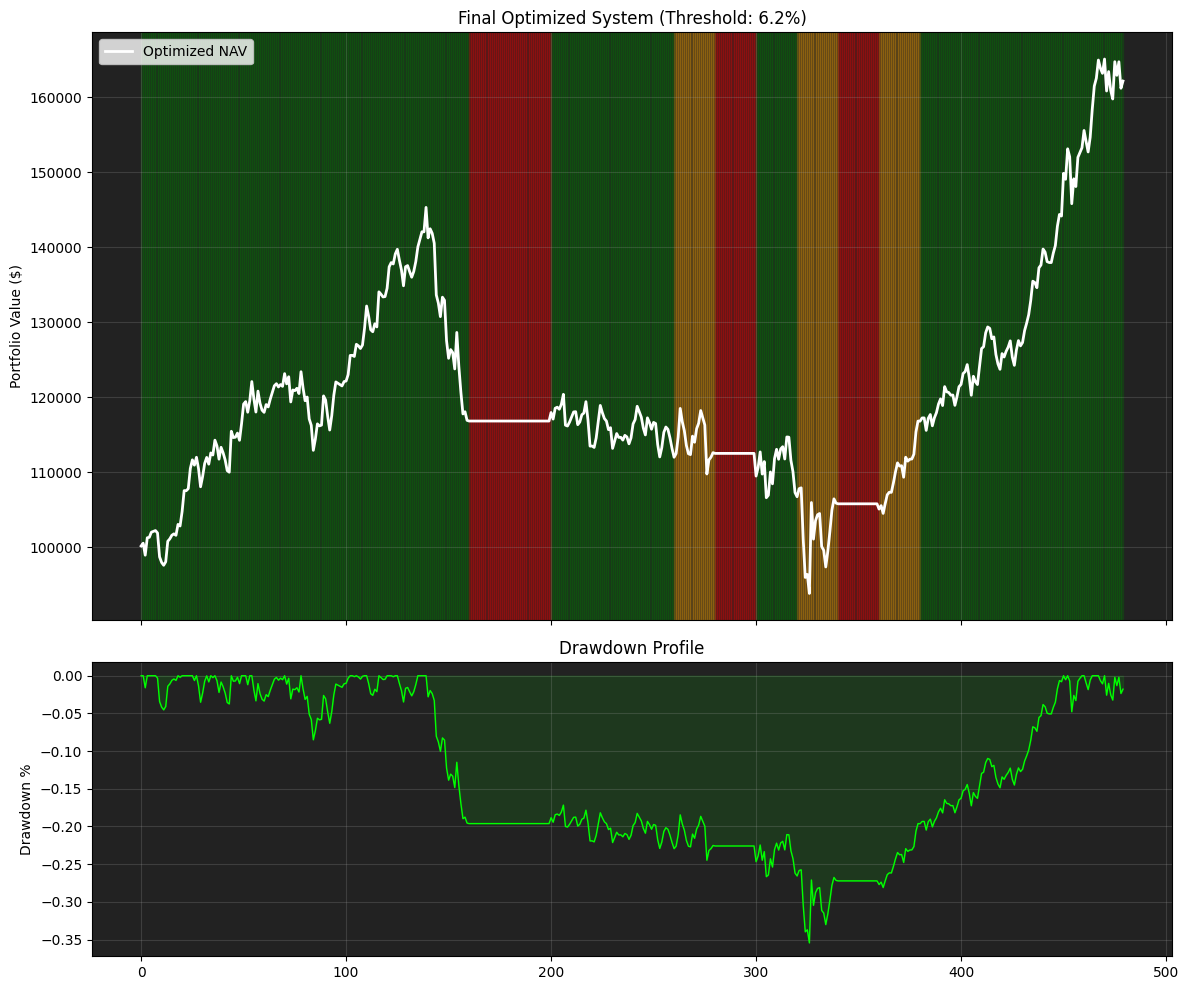

Final Return: 61.96%
Final Max Drawdown: -35.45%
Calmar Ratio: 1.75


In [1]:
# ---------------------------------------------------------
# CELL 1: IMPORTS
# ---------------------------------------------------------
import optuna
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
import config
import matplotlib.pyplot as plt
import os

# Import from our library
from rl_system import load_real_data, FinancialFeatureEngineer, PortfolioRebalanceEnv
from rl_system import precompute_agent_weights, OptimizedLogicEngine, OptimizedEnsembleBacktester, ConfigurableBoard

# ---------------------------------------------------------
# CELL 2: SETUP DATA FOR TUNING
# ---------------------------------------------------------
# Load Data
df, vix = load_real_data(config.TICKERS, config.BENCHMARK, config.START_DATE, config.END_DATE)

# Engineer Features
engineer = FinancialFeatureEngineer()
features, prices, benchmark_data = engineer.preprocess_data(df, vix_series=vix)

# Use TRAIN split for Tuning (Avoid Data Leakage!)
split_idx = int(len(prices) * 0.8)

feat_train = features[:split_idx]
price_train = prices[:split_idx]
bench_train = benchmark_data[:split_idx]

# Use TEST split for Validation
feat_test = features[split_idx:]
price_test = prices[split_idx:]
bench_test = benchmark_data[split_idx:]

# Re-initialize Environments (needed for logic engines)
train_env = PortfolioRebalanceEnv(price_train, feat_train, bench_train, lookback_window=config.WINDOW_SIZE)
test_env = PortfolioRebalanceEnv(price_test, feat_test, bench_test, lookback_window=config.WINDOW_SIZE)

print("Data prepared for tuning.")

# ---------------------------------------------------------
# CELL 3: PRE-COMPUTE WEIGHTS (Speed Hack)
# ---------------------------------------------------------
# Load models
print("Loading Models...")
bull = PPO.load(config.MODEL_BULL)
bear = PPO.load(config.MODEL_BEAR)
sniper = PPO.load(config.MODEL_SNIPER)

# Compute weights on TRAINING data once
cache_bull, cache_bear, cache_sniper, cache_indices = precompute_agent_weights(
    train_env, bull, bear, sniper
)
print("Pre-computation complete.")

# ---------------------------------------------------------
# CELL 4: OPTUNA OPTIMIZATION
# ---------------------------------------------------------
def objective(trial):
    # Search Space
    p_fast = trial.suggest_float("panic_fast", 0.010, 0.030)
    p_slow = trial.suggest_float("panic_slow", 0.015, 0.040)
    thresh = trial.suggest_float("rebal_thresh", 0.01, 0.10)
    
    # Fast Simulation (Math only, no Neural Nets)
    engine = OptimizedLogicEngine(train_env, cache_bull, cache_bear, cache_sniper, cache_indices)
    nav_curve = engine.run(p_fast, p_slow, thresh)
    
    if len(nav_curve) == 0: return -100
    
    # Metric: Calmar Ratio (Return / Max Drawdown)
    total_ret = (nav_curve[-1] / nav_curve[0]) - 1
    running_max = np.maximum.accumulate(nav_curve)
    drawdown = (nav_curve / running_max) - 1
    max_dd = np.min(drawdown)
    
    # Penalize flat lines (too safe = no trading)
    if max_dd > -0.05: return 0.0 
    
    return total_ret / abs(max_dd)

print("Starting Optuna...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("\nBest Params Found:")
print(study.best_params)

# ---------------------------------------------------------
# CELL 5: VALIDATE ON TEST DATA
# ---------------------------------------------------------
# Get Best Params
best_fast = study.best_params["panic_fast"]
best_slow = study.best_params["panic_slow"]
best_thresh = study.best_params["rebal_thresh"]

print(f"\nValidating on Test Set with: Fast={best_fast:.4f}, Slow={best_slow:.4f}, Thresh={best_thresh:.4f}")

# Initialize Production Board
board = ConfigurableBoard(config.MODEL_BULL, config.MODEL_BEAR, config.MODEL_SNIPER)

# Run Validation Backtest
validator = OptimizedEnsembleBacktester(board, test_env)
results = validator.run(best_fast, best_slow, best_thresh)

# ---------------------------------------------------------
# CELL 6: VISUALIZATION
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Equity Curve
ax1.plot(results['nav'], color='white', linewidth=2, label='Optimized NAV')
ax1.set_title(f"Final Optimized System (Threshold: {best_thresh:.1%})")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend()
ax1.grid(True, alpha=0.2)
ax1.set_facecolor('#222222')

# Regime Colors
regime_colors = {'GROWTH': 'green', 'CHOPPY': 'orange', 'CRASH': 'red'}
for start, end in zip(results.index[:-1], results.index[1:]):
    regime = results.loc[start, 'regime']
    # Simple color mapping
    color = 'blue'
    if 'GROWTH' in regime: color = 'green'
    elif 'CHOPPY' in regime: color = 'orange'
    elif 'CRASH' in regime: color = 'red'
    ax1.axvspan(start, end, color=color, alpha=0.2)

# Drawdown
running_max = results['nav'].cummax()
drawdown = (results['nav'] / running_max) - 1
ax2.plot(drawdown, color='lime', linewidth=1)
ax2.fill_between(drawdown.index, drawdown, 0, color='lime', alpha=0.1)
ax2.set_title("Drawdown Profile")
ax2.set_ylabel("Drawdown %")
ax2.grid(True, alpha=0.2)
ax2.set_facecolor('#222222')

plt.tight_layout()
plt.show()

# Final Stats
final_ret = (results['nav'].iloc[-1] / results['nav'].iloc[0]) - 1
max_dd = drawdown.min()
print(f"Final Return: {final_ret*100:.2f}%")
print(f"Final Max Drawdown: {max_dd*100:.2f}%")
print(f"Calmar Ratio: {final_ret / abs(max_dd):.2f}")